Saving RAG DataSet Email.xlsx to RAG DataSet Email.xlsx
23 emails, 50 products
['email_id', 'subject', 'message'] ['product_id', 'name', 'category', 'description', 'stock', 'seasons', 'price']


,email_id,subject,message
0,E001,Waterproof Boots Order,"Hi there, I'd like to order all the remaining ..."
1,E002,Buy Cooler Tote with extra info,"Good afternoon, I want to buy the CLR5643 Cool..."
2,E003,Need advice before I buy,"Hello, I need a new pack to carry water and sn..."
3,E004,Order for Neck Gaiters,"Hello, could you send me four of the WLB8823 W..."
4,E005,Question about the Camp Fleece Onesie,"Hi, for the CMP6610 Camp Fleece Onesie, the de..."


,product_id,name,category,description,stock,seasons,price
0,PLB7412,Polarized Trail Sunglasses,Accessories,See every root and rock clearly with our polar...,4,"Spring, Summer",34.99
1,MSH2201,Mesh Trucker Cap,Accessories,Keep cool on the trail with our breathable mes...,9,"Spring, Summer, Fall",18.00
2,WLB8823,Wool Buff Neck Gaiter,Accessories,Stay warm from your chin to your collar with o...,6,"Fall, Winter",19.00
3,LTB4490,Leather Belt with Bottle Opener,Accessories,Never get caught without an opener again. This...,3,All seasons,32.00
4,FLC6621,Fleece-Lined Trapper Hat,Accessories,Brave the cold in our fleece-lined trapper hat...,2,Winter,27.00


,email_id,subject,original_message,category,action,detected_product_ids,detected_product_names,relevance_scores,response
0,E001,Waterproof Boots Order,"Hi there, I'd like to order all the remaining ...",INFORMATION_REQUEST,ANSWER,HKB7712; HKB2298; SNB4423,Waterproof Hiking Boots; Women's Waterproof Hi...,1.00; 0.42; 0.17,Thank you for your email. Here is the informat...
1,E002,Buy Cooler Tote with extra info,"Good afternoon, I want to buy the CLR5643 Cool...",INFORMATION_REQUEST,ANSWER,CLR5643,Cooler Tote Bag,1.00,Thank you for your email. Here is the informat...
2,E003,Need advice before I buy,"Hello, I need a new pack to carry water and sn...",INFORMATION_REQUEST,ANSWER,HYD1120; DFL9982,Hydration Vest Pack; Duffel Backpack Hybrid,1.00; 1.00,Thank you for your email. Here is the informat...
3,E004,Order for Neck Gaiters,"Hello, could you send me four of the WLB8823 W...",INFORMATION_REQUEST,ANSWER,WLB8823,Wool Buff Neck Gaiter,1.00,Thank you for your email. Here is the informat...
4,E005,Question about the Camp Fleece Onesie,"Hi, for the CMP6610 Camp Fleece Onesie, the de...",INFORMATION_REQUEST,ANSWER,CMP6610; HFZ6671,Camp Fleece Onesie; Half-Zip Fleece Pullover,1.00; 0.15,Thank you for your email. Here is the informat...
5,E006,,"Hey, I was thinking about ordering the SNB4423...",COMPLAINT_OR_OTHER,IGNORE,,,,None
6,E007,Order: Beanies and Sandals,"Hi, this is Talia. Please send me 3 KDH8871 Ki...",INFORMATION_REQUEST,ANSWER,KDH8871; SND4423; SND5567,Kids' Fleece Beanie; Trail Sport Sandals; Wome...,1.00; 1.00; 0.38,Thank you for your email. Here is the informat...
7,E008,Ordering the convertible pants thing,"Hello, I'd like to order one pair of the men's...",COMPLAINT_OR_OTHER,IGNORE,,,,None
8,E009,Frage zur Fleece-Lined Trapper Hat,"Hallo, ich habe eine Frage zur FLC6621 Fleece-...",INFORMATION_REQUEST,ANSWER,FLC6621; LGG6634,Fleece-Lined Trapper Hat; Fleece-Lined Trail L...,1.00; 0.31,Thank you for your email. Here is the informat...
9,E010,Purchase Trail Sunglasses,"Hello, I would like to order 2 pairs of PLB741...",INFORMATION_REQUEST,ANSWER,PLB7412,Polarized Trail Sunglasses,1.00,Thank you for your email. Here is the informat...


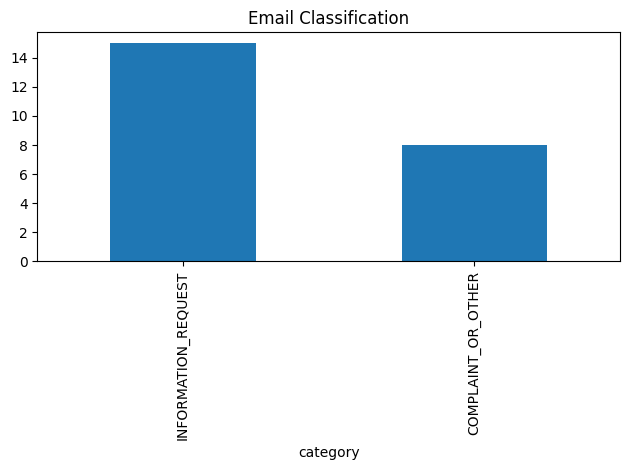

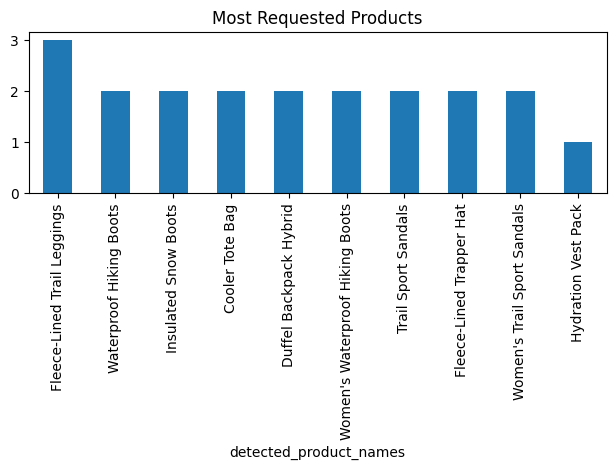

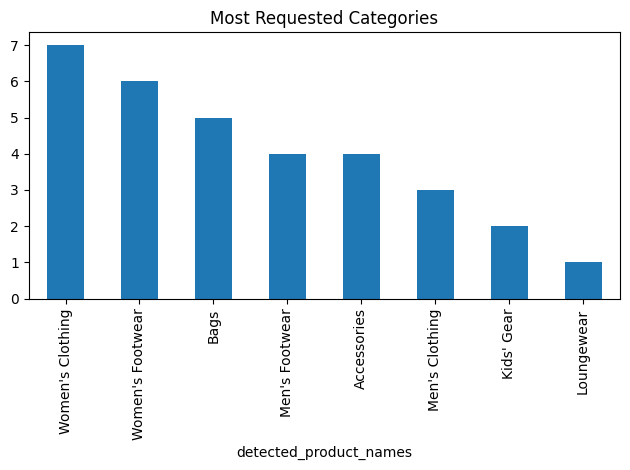

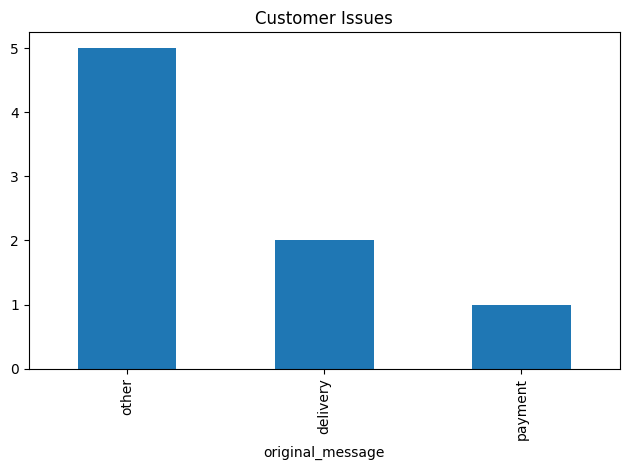

Total emails: 23
Information requests: 15 | Complaints/other: 8
Matched to products: 15 | No confident match: 0
Top products:
 detected_product_names
Fleece-Lined Trail Leggings    3
Waterproof Hiking Boots        2
Insulated Snow Boots           2
Cooler Tote Bag                2
Duffel Backpack Hybrid         2
Name: count, dtype: int64
Top categories:
 detected_product_names
Women's Clothing    7
Women's Footwear    6
Bags                5
Men's Footwear      4
Accessories         4
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!pip -q install openpyxl openai

import os, re, pandas as pd, matplotlib.pyplot as plt
from google.colab import files
from openai import OpenAI
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

THRESHOLD, TOP_K = 0.15, 3
ISSUES = {
    "delivery": ["delivery", "shipping", "late", "not received"],
    "refund/return": ["refund", "return"],
    "damaged": ["damaged", "broken", "defective"],
    "payment": ["payment", "charged", "billing"],
    "order": ["my order", "order number", "cancel"],
    "complaint": ["complaint", "wrong", "unhappy", "terrible"],
}
COMPLAINT_WORDS = sum(ISSUES.values(), [])
INFO_WORDS = ["price", "cost", "how much", "stock", "available", "do you have", "size", "material",
              "feature", "spec", "capacity", "suitable", "compare", "difference", "color"]

# API key is read from the environment only (LLM is optional, fallback works without it)
client = OpenAI() if os.getenv("OPENAI_API_KEY") else None

def ask_llm(prompt):
    r = client.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}])
    return r.choices[0].message.content.strip()

# 1. Load data (sheets detected by their columns)
sheets = pd.read_excel(list(files.upload())[0], sheet_name=None)
emails = next(d for d in sheets.values() if "email_id" in d.columns).fillna("")
products = next(d for d in sheets.values() if "product_id" in d.columns).fillna("")
products["product_id"] = products["product_id"].astype(str)
print(len(emails), "emails,", len(products), "products")
print(emails.columns.tolist(), products.columns.tolist())
display(emails.head()); display(products.head())

# 2. Preprocessing: lowercase, keep letters/numbers/IDs/prices, normalize spaces
def clean(text):
    return re.sub(r"\s+", " ", re.sub(r"[^\w\s.$-]", " ", str(text).lower())).strip()

# 3. Classification: LLM first, keyword fallback
def classify_email(text):
    if client:
        try:
            label = ask_llm("Classify this customer email. Reply with only one label:\n"
                            "INFORMATION_REQUEST (asks about product info) or "
                            "COMPLAINT_OR_OTHER (complaint, order, delivery, refund, payment, unrelated).\n\n" + text)
            if label in ("INFORMATION_REQUEST", "COMPLAINT_OR_OTHER"):
                return label
        except Exception:
            pass
    if any(w in text for w in COMPLAINT_WORDS):
        return "COMPLAINT_OR_OTHER"
    has_id = any(pid.lower() in text for pid in products["product_id"])
    return "INFORMATION_REQUEST" if has_id or any(w in text for w in INFO_WORDS) else "COMPLAINT_OR_OTHER"

# 4. Retrieval: TF-IDF + cosine similarity, exact product IDs get score 1.0
docs = products.apply(lambda p: clean(" ".join(str(p[c]) for c in
       ["product_id", "name", "category", "description", "seasons", "stock", "price"])), axis=1)
vec = TfidfVectorizer(stop_words="english")
doc_matrix = vec.fit_transform(docs)

def retrieve(text):
    sims = cosine_similarity(vec.transform([text]), doc_matrix)[0]
    for i, pid in enumerate(products["product_id"]):
        if pid.lower() in text:
            sims[i] = 1.0
    top = sims.argsort()[::-1][:TOP_K]
    return [(products.iloc[i], sims[i]) for i in top if sims[i] >= THRESHOLD]

# 5. Response generation: only from retrieved products
def generate_response(email_text, retrieved):
    if not retrieved:
        return ("Thank you for your email. We could not identify an exact matching product. "
                "Please share the product name or ID and we will gladly help.")
    if client:
        try:
            info = "\n".join(f"{p['product_id']} | {p['name']} | {p['category']} | {p['description']} | "
                             f"seasons: {p['seasons']} | stock: {p['stock']} | price: {p['price']}"
                             for p, _ in retrieved)
            return ask_llm("Write a polite, concise reply to the customer email using ONLY this product "
                           "information. Do not invent anything. Reply in the customer's language.\n\n"
                           f"Email:\n{email_text}\n\nProducts:\n{info}")
        except Exception:
            pass
    lines = [f"- {p['name']} ({p['product_id']}): {p['description']} Price: {p['price']}, Stock: {p['stock']}."
             for p, _ in retrieved]
    return "Thank you for your email. Here is the information you asked for:\n" + "\n".join(lines)

# 6. Run pipeline on all emails
rows = []
for _, e in emails.iterrows():
    raw = f"{e['subject']} {e['message']}"
    text = clean(raw)
    category = classify_email(text)
    if category == "COMPLAINT_OR_OTHER":
        found, action, response = [], "IGNORE", None
    else:
        found, action = retrieve(text), "ANSWER"
        response = generate_response(raw, found)
    rows.append({
        "email_id": e["email_id"], "subject": e["subject"], "original_message": e["message"],
        "category": category, "action": action,
        "detected_product_ids": "; ".join(p["product_id"] for p, _ in found),
        "detected_product_names": "; ".join(p["name"] for p, _ in found),
        "relevance_scores": "; ".join(f"{s:.2f}" for _, s in found),
        "response": response,
    })
out = pd.DataFrame(rows)
out.to_excel("automated_email_responses.xlsx", index=False)
display(out)

# 7. Graphs
os.makedirs("graphs", exist_ok=True)
def bar(series, title, name):
    series.head(10).plot(kind="bar", title=title)
    plt.tight_layout(); plt.savefig(f"graphs/{name}.png"); plt.show()

names = out.loc[out.detected_product_names != "", "detected_product_names"].str.split("; ").explode()
cats = names.map(products.drop_duplicates("name").set_index("name")["category"])
ignored = out.loc[out.action == "IGNORE", "original_message"].str.lower()
issue_of = lambda t: next((k for k, w in ISSUES.items() if any(x in t for x in w)), "other")

bar(out["category"].value_counts(), "Email Classification", "email_classification")
bar(names.value_counts(), "Most Requested Products", "product_demand")
bar(cats.value_counts(), "Most Requested Categories", "category_demand")
bar(ignored.map(issue_of).value_counts(), "Customer Issues", "issue_distribution")

# 8. Summary
info = out[out.category == "INFORMATION_REQUEST"]
print("Total emails:", len(out))
print("Information requests:", len(info), "| Complaints/other:", len(out) - len(info))
print("Matched to products:", (info.detected_product_ids != "").sum(),
      "| No confident match:", (info.detected_product_ids == "").sum())
print("Top products:\n", names.value_counts().head(5))
print("Top categories:\n", cats.value_counts().head(5))

# 9. Download everything as one zip
!zip -qr results.zip graphs automated_email_responses.xlsx
files.download("results.zip")